In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogFormatter, LogLocator
from scipy.special import gamma

# --- parameters (SI) ---
rho   = 11e3       # kg/m^3
U0 = 8.7e-5         # m/s
R = 3485e6    # m
omega = U0/R      # rad/s
Omega = 2*np.pi/86400    # rad/s
H     = 0.7

# --- anchoring parameters ---
kobs = 4 / R       # m^-1
hobs = 3800        # m

# --- grid ---
k0_vals   = np.logspace(-10, -4, 200)   # m^-1
hrms_vals = np.logspace(1,   4, 200)    # m

K0, HRMS = np.meshgrid(k0_vals, hrms_vals)

# --- formula ---
prefactor = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
P = prefactor * HRMS**2 * K0

# --- trajectory curve in parameter space ---
f_k0 = hobs * k0_vals * (1 + (kobs / k0_vals)**2)**((1 + H) / 2) / (np.sqrt(2 * H) * kobs)

# reference point: kobs evaluated on the trajectory
f_kobs = hobs * (1 + 1)**((1 + H) / 2) / np.sqrt(2 * H)

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 5))
levels = np.logspace(np.log10(P.min()), np.log10(P.max()), 30)
cf = ax.contourf(k0_vals, hrms_vals, P, levels=levels,
                 norm=mcolors.LogNorm(vmin=P.min(), vmax=P.max()), cmap='viridis')

cb = fig.colorbar(cf, ax=ax, label=r'$\langle\bar{\mathcal{P}}\rangle$ (W m$^{-2}$)')
cb.ax.yaxis.set_major_locator(LogLocator())
cb.ax.yaxis.set_major_formatter(LogFormatter(labelOnlyBase=True))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(k0_vals[0], k0_vals[-1])
ax.set_ylim(hrms_vals[0], hrms_vals[-1])
ax.set_xlabel(r'$k_0$ (m$^{-1}$)')
ax.set_ylabel(r'$h_\mathrm{rms}$ (m)')
ax.set_title(rf'$\mathcal{{H}}={H}$')

ax.plot(k0_vals, f_k0, 'w-', linewidth=1.5, label='trajectory')
ax.plot(kobs, f_kobs, 'w*', markersize=12, label='reference')
ax.legend()

plt.tight_layout()
plt.savefig('power_flux.pdf')
plt.show()

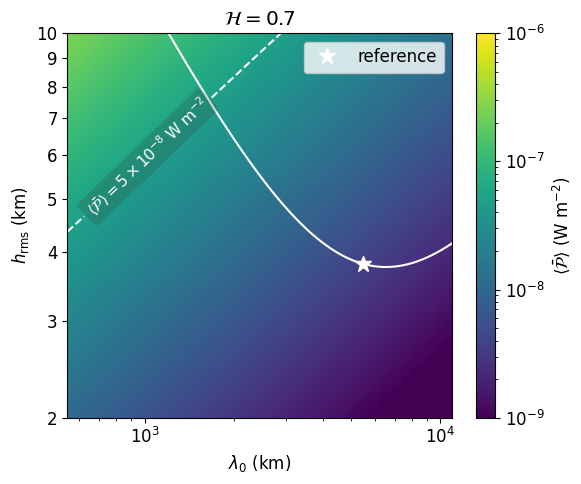

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator
from scipy.special import gamma

# --- parameters (SI) ---
rho   = 11e3
U0    = 8.7e-5
R     = 3485e3          # m  (core radius)
Omega = 2 * np.pi / 86400
H     = 0.7

# --- anchoring parameters ---
kobs = 4 / R
hobs = 2500

# --- grid ---
k0_vals   = np.logspace(np.log10(0.5*kobs), np.log10(10 * kobs), 200)
hrms_vals = np.logspace(np.log10(2e3), np.log10(1e4), 200)

lam0_vals_km = (2 * np.pi / k0_vals)[::-1] / 1e3
hrms_vals_km = hrms_vals / 1e3

K0, HRMS = np.meshgrid(k0_vals, hrms_vals)

prefactor = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
P = prefactor * HRMS**2 * K0
P_lam = P[:, ::-1]

# trajectory and reference point
f_k0     = hobs * k0_vals * (1 + (kobs / k0_vals)**2)**((1 + H) / 2) / (np.sqrt(2 * H) * kobs)
f_lam_km = f_k0[::-1] / 1e3

lam_obs_km = 2 * np.pi / kobs / 1e3
f_kobs_km  = hobs * (1 + 1)**((1 + H) / 2) / np.sqrt(2 * H) / 1e3

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cb_ticks = [1e-9, 1e-8, 1e-7, 1e-6]
cf = ax.pcolormesh(lam0_vals_km, hrms_vals_km, P_lam,
                   norm=mcolors.LogNorm(vmin=cb_ticks[0], vmax=cb_ticks[-1]),
                   cmap='viridis', shading='auto')

cb = fig.colorbar(cf, ax=ax, label=r'$\langle\bar{\mathcal{P}}\rangle$ (W m$^{-2}$)')
cb.ax.set_yticks(cb_ticks)
cb.ax.set_yticklabels([r'$10^{-9}$', r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lam0_vals_km[0], lam0_vals_km[-1])
ax.set_ylim(hrms_vals_km[0], hrms_vals_km[-1])

# ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 3, 5]))
# ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(minor_thresholds=(10, 0.5)))
# ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(1, 10)))
# ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.yaxis.set_major_locator(LogLocator(subs=np.arange(1, 10)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel(r'$\lambda_0$ (km)')
ax.set_ylabel(r'$h_\mathrm{rms}$ (km)')
ax.set_title(rf'$\mathcal{{H}}={H}$')

ax.plot(lam0_vals_km, f_lam_km, 'w-', linewidth=1.5)
ax.plot(lam_obs_km, f_kobs_km, 'w*', markersize=12, label='reference')

# iso-power arc with label
cs = ax.contour(lam0_vals_km, hrms_vals_km, P_lam, levels=[5e-8],
                colors='white', linewidths=1.5, linestyles='--')
labels = ax.clabel(cs, fmt=r'$\langle\bar{\mathcal{P}}\rangle=5\times10^{-8}$ W m$^{-2}$',
                   fontsize=11, colors='white')
for lbl in labels:
    lbl.set_bbox(dict(boxstyle='round,pad=0.3', fc='0.2', ec='none', alpha=0.2))

ax.legend()

plt.tight_layout()
plt.savefig('trade_off_map_H=7e-1.pdf')
plt.show()

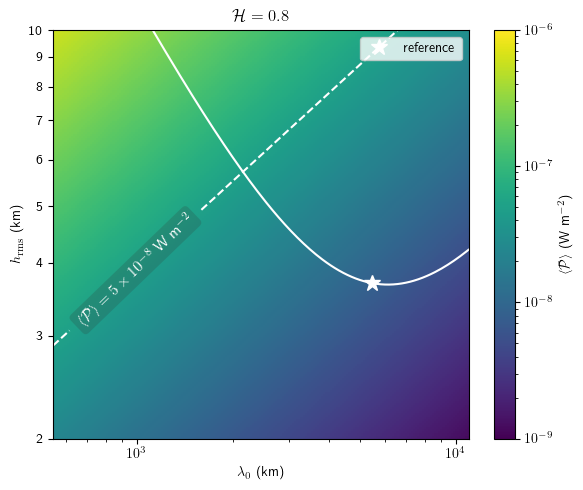

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator
from scipy.special import gamma

# --- parameters (SI) ---
rho   = 11e3
U0    = 8.7e-5
R     = 3485e3          # m  (core radius)
Omega = 2 * np.pi / 86400
H     = 0.8

# --- anchoring parameters ---
kobs = 4 / R
hobs = 2500

# --- grid ---
k0_vals   = np.logspace(np.log10(0.5*kobs), np.log10(10 * kobs), 200)
hrms_vals = np.logspace(np.log10(2e3), np.log10(1e4), 200)

lam0_vals_km = (2 * np.pi / k0_vals)[::-1] / 1e3
hrms_vals_km = hrms_vals / 1e3

K0, HRMS = np.meshgrid(k0_vals, hrms_vals)

prefactor = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
P = prefactor * HRMS**2 * K0
P_lam = P[:, ::-1]

# trajectory and reference point
f_k0     = hobs * k0_vals * (1 + (kobs / k0_vals)**2)**((1 + H) / 2) / (np.sqrt(2 * H) * kobs)
f_lam_km = f_k0[::-1] / 1e3

lam_obs_km = 2 * np.pi / kobs / 1e3
f_kobs_km  = hobs * (1 + 1)**((1 + H) / 2) / np.sqrt(2 * H) / 1e3

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cb_ticks = [1e-9, 1e-8, 1e-7, 1e-6]
cf = ax.pcolormesh(lam0_vals_km, hrms_vals_km, P_lam,
                   norm=mcolors.LogNorm(vmin=cb_ticks[0], vmax=cb_ticks[-1]),
                   cmap='viridis', shading='auto')

cb = fig.colorbar(cf, ax=ax, label=r'$\langle\bar{\mathcal{P}}\rangle$ (W m$^{-2}$)')
cb.ax.set_yticks(cb_ticks)
cb.ax.set_yticklabels([r'$10^{-9}$', r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lam0_vals_km[0], lam0_vals_km[-1])
ax.set_ylim(hrms_vals_km[0], hrms_vals_km[-1])

# ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 3, 5]))
# ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(minor_thresholds=(10, 0.5)))
# ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(1, 10)))
# ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.yaxis.set_major_locator(LogLocator(subs=np.arange(1, 10)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel(r'$\lambda_0$ (km)')
ax.set_ylabel(r'$h_\mathrm{rms}$ (km)')
ax.set_title(rf'$\mathcal{{H}}={H}$')

ax.plot(lam0_vals_km, f_lam_km, 'w-', linewidth=1.5)
ax.plot(lam_obs_km, f_kobs_km, 'w*', markersize=12, label='reference')

# iso-power arc with label
cs = ax.contour(lam0_vals_km, hrms_vals_km, P_lam, levels=[5e-8],
                colors='white', linewidths=1.5, linestyles='--')
labels = ax.clabel(cs, fmt=r'$\langle\bar{\mathcal{P}}\rangle=5\times10^{-8}$ W m$^{-2}$',
                   fontsize=11, colors='white')
for lbl in labels:
    lbl.set_bbox(dict(boxstyle='round,pad=0.3', fc='0.2', ec='none', alpha=0.2))

ax.legend()

plt.tight_layout()
plt.savefig('trade_off_map_H=8e-1.pdf')
plt.show()

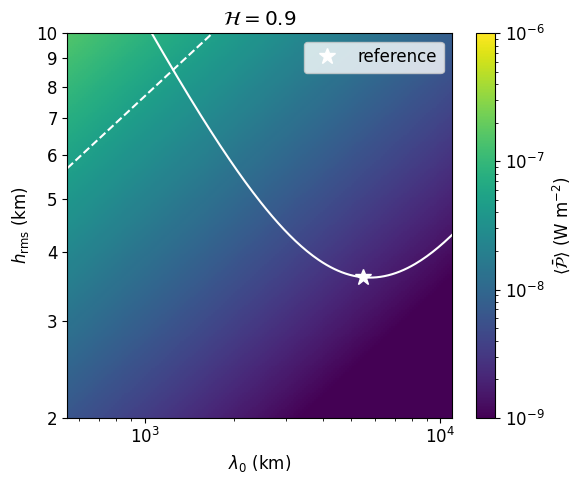

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator
from scipy.special import gamma

# --- parameters (SI) ---
rho   = 11e3
U0    = 8.7e-5
R     = 3485e3          # m  (core radius)
Omega = 2 * np.pi / 86400
H     = 0.9

# --- anchoring parameters ---
kobs = 4 / R
hobs = 2500

# --- grid ---
k0_vals   = np.logspace(np.log10(0.5*kobs), np.log10(10 * kobs), 200)
hrms_vals = np.logspace(np.log10(2e3), np.log10(1e4), 200)

lam0_vals_km = (2 * np.pi / k0_vals)[::-1] / 1e3
hrms_vals_km = hrms_vals / 1e3

K0, HRMS = np.meshgrid(k0_vals, hrms_vals)

prefactor = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
P = prefactor * HRMS**2 * K0
P_lam = P[:, ::-1]

# trajectory and reference point
f_k0     = hobs * k0_vals * (1 + (kobs / k0_vals)**2)**((1 + H) / 2) / (np.sqrt(2 * H) * kobs)
f_lam_km = f_k0[::-1] / 1e3

lam_obs_km = 2 * np.pi / kobs / 1e3
f_kobs_km  = hobs * (1 + 1)**((1 + H) / 2) / np.sqrt(2 * H) / 1e3

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cb_ticks = [1e-9, 1e-8, 1e-7, 1e-6]
cf = ax.pcolormesh(lam0_vals_km, hrms_vals_km, P_lam,
                   norm=mcolors.LogNorm(vmin=cb_ticks[0], vmax=cb_ticks[-1]),
                   cmap='viridis', shading='auto')

cb = fig.colorbar(cf, ax=ax, label=r'$\langle\bar{\mathcal{P}}\rangle$ (W m$^{-2}$)')
cb.ax.set_yticks(cb_ticks)
cb.ax.set_yticklabels([r'$10^{-9}$', r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lam0_vals_km[0], lam0_vals_km[-1])
ax.set_ylim(hrms_vals_km[0], hrms_vals_km[-1])

# ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 3, 5]))
# ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(minor_thresholds=(10, 0.5)))
# ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(1, 10)))
# ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.yaxis.set_major_locator(LogLocator(subs=np.arange(1, 10)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel(r'$\lambda_0$ (km)')
ax.set_ylabel(r'$h_\mathrm{rms}$ (km)')
ax.set_title(rf'$\mathcal{{H}}={H}$')

ax.plot(lam0_vals_km, f_lam_km, 'w-', linewidth=1.5)
ax.plot(lam_obs_km, f_kobs_km, 'w*', markersize=12, label='reference')

# iso-power arc with label
cs = ax.contour(lam0_vals_km, hrms_vals_km, P_lam, levels=[5e-8],
                colors='white', linewidths=1.5, linestyles='--')
labels = ax.clabel(cs, fmt=r'$\langle\bar{\mathcal{P}}\rangle=5\times10^{-8}$ W m$^{-2}$',
                   fontsize=11, colors='white')
for lbl in labels:
    lbl.set_bbox(dict(boxstyle='round,pad=0.3', fc='0.2', ec='none', alpha=0.2))

ax.legend()

plt.tight_layout()
plt.savefig('trade_off_map_H=9e-1.pdf')
plt.show()

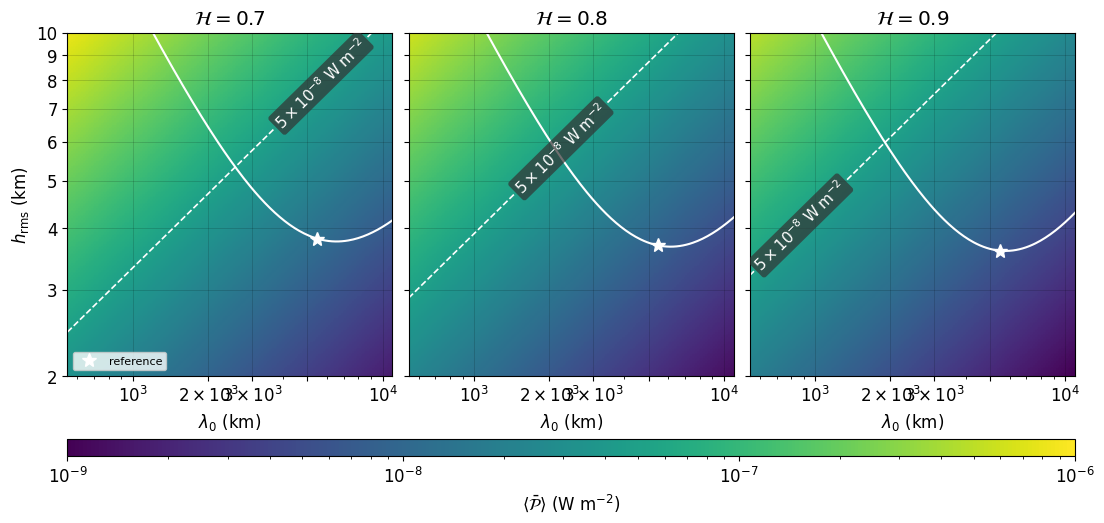

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator
from scipy.special import gamma

# --- fixed parameters ---
rho   = 11e3
U0    = 8.7e-5
R     = 3485e3
Omega = 2 * np.pi / 86400
kobs  = 4 / R
hobs  = 2500

k0_vals   = np.logspace(np.log10(0.5*kobs), np.log10(10 * kobs), 200)
hrms_vals = np.logspace(np.log10(2e3), np.log10(1e4), 200)
lam0_vals_km = (2 * np.pi / k0_vals)[::-1] / 1e3
hrms_vals_km = hrms_vals / 1e3
K0, HRMS = np.meshgrid(k0_vals, hrms_vals)

cb_ticks      = [1e-9, 1e-8, 1e-7, 1e-6]
cb_ticklabels = [r'$10^{-9}$', r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$']
norm = mcolors.LogNorm(vmin=cb_ticks[0], vmax=cb_ticks[-1])
lam_obs_km = 2 * np.pi / kobs / 1e3

def fill_panel(ax, H, show_ylabel=False):
    prefactor = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
    P_lam = (prefactor * HRMS**2 * K0)[:, ::-1]

    f_lam_km  = (hobs * k0_vals * (1 + (kobs/k0_vals)**2)**((1+H)/2)
                 / (np.sqrt(2*H) * kobs))[::-1] / 1e3
    f_kobs_km = hobs * 2**((1+H)/2) / np.sqrt(2*H) / 1e3

    cf = ax.pcolormesh(lam0_vals_km, hrms_vals_km, P_lam,
                       norm=norm, cmap='viridis', shading='auto')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lam0_vals_km[0], lam0_vals_km[-1])
    ax.set_ylim(hrms_vals_km[0], hrms_vals_km[-1])

    ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 3, 5]))
    ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(minor_thresholds=(10, 0.5)))
    ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(1, 10)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    ax.yaxis.set_major_locator(LogLocator(subs=np.arange(1, 10)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax.grid(which='major', color='black', alpha=0.2, linewidth=0.5)

    ax.set_xlabel(r'$\lambda_0$ (km)')
    ax.set_title(rf'$\mathcal{{H}}={H}$')
    if show_ylabel:
        ax.set_ylabel(r'$h_\mathrm{rms}$ (km)')

    ax.plot(lam0_vals_km, f_lam_km, 'w-', linewidth=1.5)
    ax.plot(lam_obs_km, f_kobs_km, 'w*', markersize=10, label='reference')
    if show_ylabel:
        ax.legend(fontsize=8)

    cs = ax.contour(lam0_vals_km, hrms_vals_km, P_lam, levels=[5e-8],
                    colors='white', linewidths=1.2, linestyles='--')
    lbls = ax.clabel(cs, fmt=r'$5\times10^{-8}$ W m$^{-2}$', fontsize=11, colors='white')
    for lbl in lbls:
        lbl.set_bbox(dict(boxstyle='round,pad=0.2', fc='0.2', ec='none', alpha=0.7))

    return cf

H_vals = [0.7, 0.8, 0.9]

fig = plt.figure(figsize=(13, 5.5))
gs  = GridSpec(2, 3, figure=fig, height_ratios=[1, 0.05], hspace=0.35, wspace=0.05)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
cax = fig.add_subplot(gs[1, :])

for i, (ax, H) in enumerate(zip([ax0, ax1, ax2], H_vals)):
    cf = fill_panel(ax, H, show_ylabel=(i == 0))
    if i > 0:
        plt.setp(ax.get_yticklabels(), visible=False)

cb = fig.colorbar(cf, cax=cax, orientation='horizontal',
                  label=r'$\langle\bar{\mathcal{P}}\rangle$ (W m$^{-2}$)')
cb.ax.set_xticks(cb_ticks)
cb.ax.set_xticklabels(cb_ticklabels)

plt.savefig('trade_off_map_combined.pdf')
plt.show()

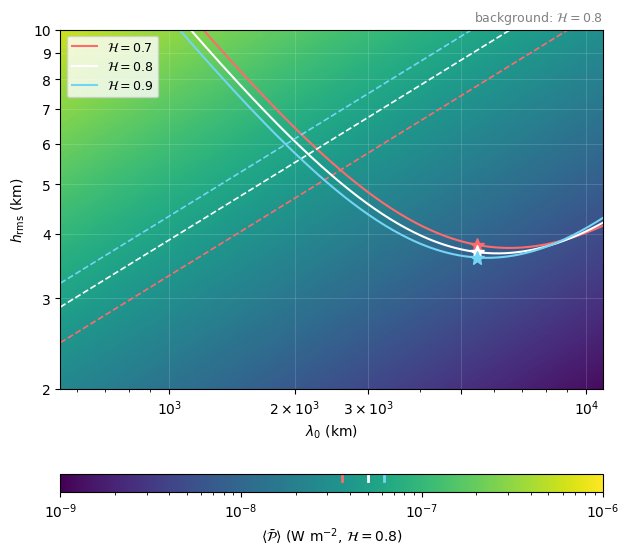

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator
from scipy.special import gamma

# --- fixed parameters ---
rho   = 11e3
U0    = 8.7e-5
R     = 3485e3
Omega = 2 * np.pi / 86400
kobs  = 4 / R
hobs  = 2500

k0_vals   = np.logspace(np.log10(0.5*kobs), np.log10(10 * kobs), 200)
hrms_vals = np.logspace(np.log10(2e3), np.log10(1e4), 200)
lam0_vals_km = (2 * np.pi / k0_vals)[::-1] / 1e3
hrms_vals_km = hrms_vals / 1e3
K0, HRMS = np.meshgrid(k0_vals, hrms_vals)
lam_obs_km = 2 * np.pi / kobs / 1e3

H_vals  = [0.7, 0.8, 0.9]
colors  = ['#FF6B6B', '#FFFFFF', '#74D4F4']   # red, white, cyan
H_ref   = 0.8
P_ISO   = 5e-8

def pf(H):
    return 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))

# Background: reference colormap at H_ref
P_ref_lam = (pf(H_ref) * HRMS**2 * K0)[:, ::-1]

cb_ticks      = [1e-9, 1e-8, 1e-7, 1e-6]
cb_ticklabels = [r'$10^{-9}$', r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$']
norm = mcolors.LogNorm(vmin=cb_ticks[0], vmax=cb_ticks[-1])

fig = plt.figure(figsize=(7, 6))
gs  = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.05], hspace=0.45)
ax  = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

cf = ax.pcolormesh(lam0_vals_km, hrms_vals_km, P_ref_lam,
                   norm=norm, cmap='viridis', shading='auto')

ax.set_xscale('log');  ax.set_yscale('log')
ax.set_xlim(lam0_vals_km[0], lam0_vals_km[-1])
ax.set_ylim(hrms_vals_km[0], hrms_vals_km[-1])
ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 3, 5]))
ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(minor_thresholds=(10, 0.5)))
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(1, 10)))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_major_locator(LogLocator(subs=np.arange(1, 10)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which='major', color='white', alpha=0.2, linewidth=0.5)
ax.set_xlabel(r'$\lambda_0$ (km)')
ax.set_ylabel(r'$h_\mathrm{rms}$ (km)')
ax.set_title(rf'background: $\mathcal{{H}}={H_ref}$', fontsize=9, loc='right', color='grey')

# Overlay: trajectory, reference point, iso-P arc for each H
for H, color in zip(H_vals, colors):
    P_lam = (pf(H) * HRMS**2 * K0)[:, ::-1]
    f_lam_km  = (hobs * k0_vals * (1 + (kobs/k0_vals)**2)**((1+H)/2)
                 / (np.sqrt(2*H) * kobs))[::-1] / 1e3
    f_kobs_km = hobs * 2**((1+H)/2) / np.sqrt(2*H) / 1e3

    ax.plot(lam0_vals_km, f_lam_km, '-',  color=color, linewidth=1.5,
            label=rf'$\mathcal{{H}}={H}$')
    ax.plot(lam_obs_km, f_kobs_km,  '*',  color=color, markersize=10)
    ax.contour(lam0_vals_km, hrms_vals_km, P_lam, levels=[P_ISO],
               colors=[color], linewidths=1.2, linestyles='--')

ax.legend(fontsize=9, loc='upper left')

# Colorbar — label is for H_ref; markers show where P_ISO falls for each H
cb = fig.colorbar(cf, cax=cax, orientation='horizontal',
                  label=rf'$\langle\bar{{\mathcal{{P}}}}\rangle$ (W m$^{{-2}}$, $\mathcal{{H}}={H_ref}$)')
cb.ax.set_xticks(cb_ticks)
cb.ax.set_xticklabels(cb_ticklabels)

# Vertical marks on colorbar: P_ISO for H maps to P_ref = P_ISO * pf(H_ref)/pf(H)
for H, color in zip(H_vals, colors):
    p_on_ref = P_ISO * pf(H_ref) / pf(H)
    if cb_ticks[0] <= p_on_ref <= cb_ticks[-1]:
        cb.ax.axvline(x=p_on_ref, color=color, linewidth=2, ymin=0.6, ymax=1.0)

plt.savefig('trade_off_map_single.pdf')
plt.show()

/var/folders/y5/60n3xc9s3c3d6gbnghlwvf7h0000gp/T/ipykernel_71262/2627677853.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _base = plt.cm.get_cmap('viridis')


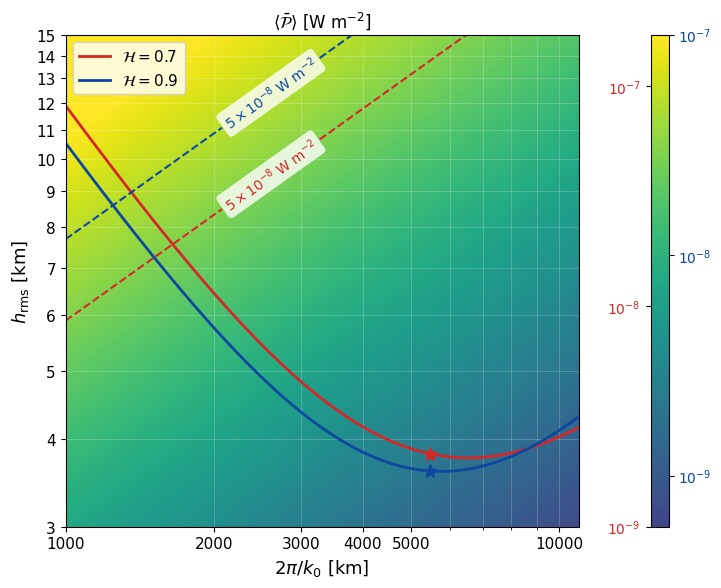

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator
from scipy.special import gamma

plt.rcParams.update({'font.size': 12})

# --- fixed parameters ---
rho   = 11e3
U0    = 8.7e-5
R     = 3485e3
Omega = 2 * np.pi / 86400
kobs  = 4 / R
hobs  = 2500

k0_vals   = np.logspace(np.log10(0.5*kobs), np.log10(2*np.pi / (1000e3)), 200)
hrms_vals = np.logspace(np.log10(3e3), np.log10(1.5e4), 200)
lam0_vals_km = (2 * np.pi / k0_vals)[::-1] / 1e3
hrms_vals_km = hrms_vals / 1e3
K0, HRMS = np.meshgrid(k0_vals, hrms_vals)
lam_obs_km = 2 * np.pi / kobs / 1e3

H_vals = [0.7,       0.9      ]
colors = ['#D62728', '#0D47A1']  # crimson red, very dark navy

P_ISO = 5e-8

def pf(H):
    return 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))

Q_lam = (HRMS**2 * K0)[:, ::-1]

P_ticks      = [1e-9, 1e-8, 1e-7]
P_ticklabels = [r'$10^{-9}$', r'$10^{-8}$', r'$10^{-7}$']

Q_vmin = min(p / pf(H) for p in P_ticks for H in H_vals)
Q_vmax = max(p / pf(H) for p in P_ticks for H in H_vals)
norm = mcolors.LogNorm(vmin=Q_vmin, vmax=Q_vmax)

# Use only the upper portion of viridis (0.3→1.0) so the dark-purple end
# doesn't swallow the navy H=0.9 curve; stretch it to cover the full data range.
_base = plt.cm.get_cmap('viridis')
cmap = mcolors.LinearSegmentedColormap.from_list(
    'viridis_trunc', _base(np.linspace(0.20, 1.0, 256))
)

lam_lbl = 10**(np.log10(lam0_vals_km[0])
               + 0.40 * (np.log10(lam0_vals_km[-1]) - np.log10(lam0_vals_km[0])))

cax_rect = [0.73, 0.10, 0.020, 0.82]

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_axes([0.08, 0.10, 0.57, 0.82])
cax = fig.add_axes(cax_rect)

cf = ax.pcolormesh(lam0_vals_km, hrms_vals_km, Q_lam,
                   norm=norm, cmap=cmap, shading='auto', rasterized=True)

ax.set_xscale('log');  ax.set_yscale('log')
ax.set_xlim(lam0_vals_km[0], lam0_vals_km[-1])
ax.set_ylim(hrms_vals_km[0], hrms_vals_km[-1])
ax.xaxis.set_major_locator(mticker.FixedLocator([1000, 2000, 3000, 4000, 5000, 10000]))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(1, 10)))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_major_locator(mticker.FixedLocator([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
# ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(which='major', labelsize=11)
ax.grid(which='both', color='white', alpha=0.2, linewidth=0.7)
ax.set_xlabel(r'$2\pi/k_0$ [km]', fontsize=13)
ax.set_ylabel(r'$h_\mathrm{rms}$ [km]', fontsize=13)
ax.set_title(r'$\langle\bar{\mathcal{P}}\rangle$ [W m$^{-2}$]', fontsize=12)

for H, color in zip(H_vals, colors):
    P_lam = (pf(H) * HRMS**2 * K0)[:, ::-1]
    f_lam_km  = (hobs * k0_vals * (1 + (kobs/k0_vals)**2)**((1+H)/2)
                 / (np.sqrt(2*H) * kobs))[::-1] / 1e3
    f_kobs_km = hobs * 2**((1+H)/2) / np.sqrt(2*H) / 1e3
    ax.plot(lam0_vals_km, f_lam_km, '-',  color=color, linewidth=2.0,
            label=rf'$\mathcal{{H}}={H}$')
    ax.plot(lam_obs_km, f_kobs_km,  '*',  color=color, markersize=10)
    cs = ax.contour(lam0_vals_km, hrms_vals_km, P_lam, levels=[P_ISO],
                    colors=[color], linewidths=1.5, linestyles='--')
    hrms_lbl_km = np.sqrt(P_ISO / (pf(H) * 2 * np.pi / (lam_lbl * 1e3))) / 1e3
    lbls = ax.clabel(cs, fmt=r'$5\times10^{-8}$ W m$^{-2}$', fontsize=10, colors=color,
                     manual=[(lam_lbl, hrms_lbl_km)])
    for lbl in lbls:
        lbl.set_bbox(dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8))

ax.legend(fontsize=11, loc='upper left')

cb = fig.colorbar(cf, cax=cax, orientation='vertical')
cax.set_yticks([])
cax.yaxis.set_minor_locator(mticker.NullLocator())

# Two independent axes overlaid on cax — one P scale per side, bypassing secondary_yaxis quirks
for H, color, side in [(0.7, colors[0], 'left'), (0.9, colors[1], 'right')]:
    ax_p = fig.add_axes(cax_rect)
    ax_p.set_yscale('log')
    ax_p.set_ylim(Q_vmin * pf(H), Q_vmax * pf(H))  # P range, aligned to the Q colorbar
    ax_p.set_yticks(P_ticks)
    ax_p.set_yticklabels(P_ticklabels, color=color, fontsize=10)
    ax_p.yaxis.set_ticks_position(side)
    ax_p.yaxis.set_minor_locator(mticker.NullLocator())
    ax_p.patch.set_visible(False)
    for spine in ax_p.spines.values():
        spine.set_visible(False)
    ax_p.set_xticks([])

plt.savefig('trade_off_map.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [72]:
import numpy as np
from scipy.special import gamma

rho   = 11e3        # kg m^-3
U0    = 8.7e-5      # m s^-1
Omega = 2 * np.pi / 86400  # rad s^-1

def power_flux(hrms, k0, H):
    """Mean power flux <P> in W m^-2.

    Parameters
    ----------
    hrms : float  rms topography amplitude (m)
    k0   : float  dominant wavenumber (m^-1)
    H    : float  Hurst exponent (must satisfy 0.5 < H < 1)
    """
    prefactor = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
    return prefactor * hrms**2 * k0

# --- example ---
hrms = 6e3          # m
l    = 8
k0   = l / 3485e3   # m^-1  (l spherical harmonic degrees over core radius)
H    = 0.7
P = power_flux(hrms, k0, H)
print(f"hrms = {hrms} m,  k0 = {k0:.3e} m^-1,  H = {H}")
print(f"<P>  = {P:.3e} W m^-2")


hrms = 6000.0 m,  k0 = 2.296e-06 m^-1,  H = 0.7
<P>  = 1.897e-08 W m^-2
